In [94]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import globals as gl
from sklearn.linear_model import Ridge
import PcmPy as pcm
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import r2_score

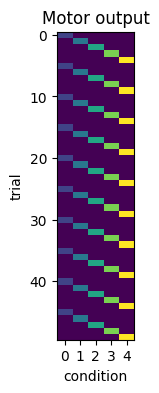

In [95]:
dy = 5               # number of outputs (index, ring)
fingers = np.arange(dy)
P = 300
Bl = 10
N = dy * Bl               # number of trials

part_vec = np.repeat(np.arange(Bl), N // Bl)
cond_vec = np.tile(fingers, N // dy)
Y = pcm.indicator(cond_vec) * np.arange(1, dy+1)

fig, ax = plt.subplots(figsize=(1, 4))

ax.imshow(Y, aspect='auto')
ax.set_xticks(np.arange(N // Bl))
ax.set_xlabel('condition')
ax.set_ylabel('trial')
ax.set_title('Motor output')

plt.show()

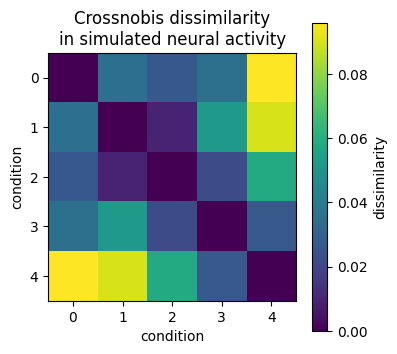

In [96]:
rng_basis = np.random.default_rng(0)
A = rng_basis.standard_normal((P, P))
Q, R = np.linalg.qr(A)
U_pot, U_null = Q[:, :dy], Q[:, dy:]

common = .5
B_pot = np.eye(dy) + common - np.diag(np.zeros(dy) + common)
X_pot = Y @ B_pot @ U_pot.T

rng_noise = np.random.default_rng(2)
X_null = rng_noise.standard_normal((N, P - dy)) @ U_null.T
SNR = 1
X = X_pot + SNR * X_null
G, _ = pcm.est_G_crossval(X, cond_vec, part_vec)
G_pot, _ = pcm.est_G_crossval(X_pot, cond_vec, part_vec)
G_null, _ = pcm.est_G_crossval(X_null, cond_vec, part_vec)
D = pcm.G_to_dist(G)
D_pot = pcm.G_to_dist(G_pot)
D_null = pcm.G_to_dist(G_null)

fig, ax = plt.subplots(figsize=(4, 4))

h = ax.imshow(D,)
ax.set_xlabel('condition')
ax.set_ylabel('condition')
ax.set_title('Crossnobis dissimilarity\nin simulated neural activity')
fig.colorbar(h, label='dissimilarity')

plt.show()

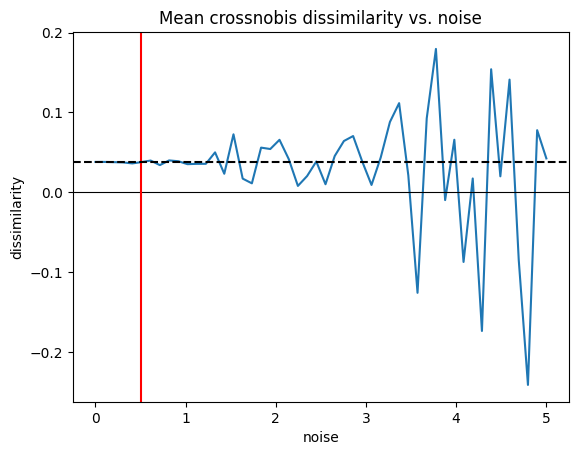

In [97]:
rng_noise = np.random.default_rng(2)
SNR = np.linspace(0, 5, 50)
D = np.zeros_like(SNR, dtype=float)

for i, snr in enumerate(SNR):
    acc = 0.0
    Z = rng_noise.standard_normal((N, P - dy))
    X_null_tmp = Z @ U_null.T
    X_tmp = X_pot + snr * X_null_tmp
    G, _ = pcm.est_G_crossval(X_tmp, cond_vec, part_vec)
    D[i] = pcm.G_to_dist(G).mean()

fig, ax = plt.subplots()

ax.plot(SNR, D)
ax.axhline(0, color='k', lw=.8)
ax.axvline(.5, color='r')
ax.axhline(D_pot.mean(), color='k', ls='--')
ax.set_xlabel('noise')
ax.set_ylabel('dissimilarity')
ax.set_title('Mean crossnobis dissimilarity vs. noise')

plt.show()

In [98]:
scaler = StandardScaler(with_mean=True, with_std=True)

alpha = X.shape[0] * 10 # moderate shrinkage; adjust if needed
logo  = LeaveOneGroupOut()

# storage
pred_total = np.zeros_like(Y)
pred_pot = np.zeros_like(Y)
pred_null = np.zeros_like(Y)

# optional: collect subspaces per fold
U_pot_list = []

for tr, te in logo.split(X, Y, groups=part_vec):
    # 1) scale X on train, center Y on train
    xsc = scaler.fit(X[tr])
    Xtr = xsc.transform(X[tr])
    Xte = xsc.transform(X[te])

    # 2) ridge fit (no intercept because Y centered)
    reg = Ridge(alpha=alpha, fit_intercept=True)
    reg.fit(Xtr, Y[tr])

    # 3) potent basis from SVD of B
    B = reg.coef_.T                      # (P, dy)
    b0 = reg.intercept_
    U, S, Vt = np.linalg.svd(B, full_matrices=False)
    tol = 1e-6 * S[0]       # scale relative to largest singular value
    r = max(1, int((S > tol).sum()))
    U_pot = U[:, :r]                     # (P, r)
    P_pot = U_pot @ U_pot.T              # (P, P)
    P_null = np.eye(B.shape[0]) - P_pot

    # 4) predictions
    Yhat_total = Xte @ B + b0
    Yhat_pot   = (Xte @ P_pot)  @ B + b0
    Yhat_null  = (Xte @ P_null) @ B + b0

    # 5) inverse-transform Y back to raw units for scoring/output
    pred_total[te] = Yhat_total
    pred_pot[te]   = Yhat_pot
    pred_null[te]  = Yhat_null

# evaluation
print("R² total per output:", r2_score(Y, pred_total, multioutput='raw_values'))
print("R² potent per output:", r2_score(Y, pred_pot,   multioutput='raw_values'))
print("R² null per output:",   r2_score(Y, pred_null,  multioutput='raw_values'))

R² total per output: [0.11007889 0.12367106 0.03746981 0.05307495 0.21102868]
R² potent per output: [0.11007889 0.12367106 0.03746981 0.05307495 0.21102868]
R² null per output: [ 2.22044605e-16  4.44089210e-16 -2.22044605e-16  5.55111512e-16
  0.00000000e+00]


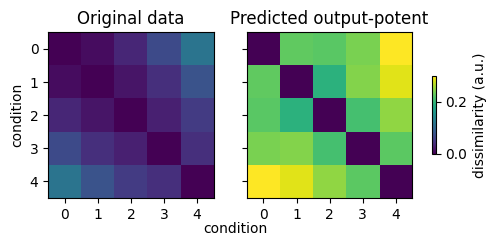

In [105]:
reg = Ridge(alpha=alpha, fit_intercept=True)
Xs = scaler.fit_transform(X)
reg.fit(Xs, Y)
B = reg.coef_.T  # (P, dy)
b0 = reg.intercept_
U, S, Vt = np.linalg.svd(B, full_matrices=False)
tol = 1e-6 * S[0]  # scale relative to largest singular value
r = max(1, int((S > tol).sum()))
U_pot = U[:, :r]  # (P, r)
P_pot = U_pot @ U_pot.T  # (P, P)
P_null = np.eye(B.shape[0]) - P_pot
X_pot_hat = scaler.inverse_transform(Xs @ P_pot)
X_null_hat = scaler.inverse_transform(Xs @ P_null)
G_pot_hat, _ = pcm.est_G_crossval(X_pot_hat, cond_vec, part_vec)
D_pot_hat = pcm.G_to_dist(G_pot_hat)

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(5, 2.5))

vmin=0
vmax=max(D_pot.max(), D_pot_hat.max())

axs[0].imshow(D_pot, vmin=vmin, vmax=vmax)
axs[1].imshow(D_pot_hat, vmin=vmin, vmax=vmax)
axs[0].set_title('Original data')
axs[1].set_title('Predicted output-potent')
axs[0].set_ylabel('condition')
axs[0].set_yticks(np.arange(N // Bl))
axs[0].set_xticks(axs[0].get_yticks())
axs[1].set_xticks(axs[0].get_yticks())
fig.supxlabel('condition', fontsize=10)
cax = axs[0].get_images()[0]
cbar = fig.colorbar(cax, ax=axs, orientation='vertical', fraction=.01)
cbar.set_label('dissimilarity (a.u.)')
plt.show()

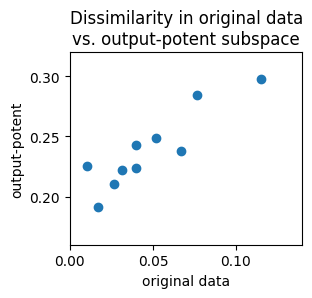

In [122]:
fig, ax = plt.subplots(figsize=(3, 2.5))

ax.scatter(D_pot[np.tri(N // Bl, k=-1, dtype=bool)].flatten(), D_pot_hat[np.tri(N // Bl, k=-1, dtype=bool)].flatten())
ax.set_title('Dissimilarity in original data\nvs. output-potent subspace')
ax.set_xlabel('original data')
ax.set_ylabel('output-potent')
ax.set_ylim(.16, .32)
ax.set_xlim(0, .14)
plt.show()